(-0.5, 1279.5, 719.5, -0.5)

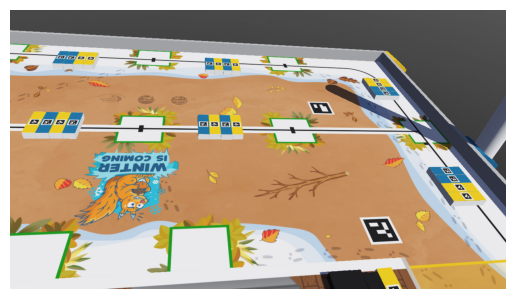

In [6]:
# Fix matplotlib/IPython compatibility issue
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get

# load image using opencv
import cv2
import numpy as np
import matplotlib.pyplot as plt

from extrinsic_calibration import (
    show, detect_green_squares, estimate_square_poses, draw_poses
)


# Load an image using OpenCV
image = cv2.imread('../../ressources/watchtower_view.png')

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the image using matplotlib
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Hide the axis

In [3]:
aruco_dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_parameters =  cv2.aruco.DetectorParameters()
aruco_detector = cv2.aruco.ArucoDetector(aruco_dictionary, aruco_parameters)

markerCorners, markerIds, _ = aruco_detector.detectMarkers(image)

print(markerCorners[0])
# print(markerIds)

[[[1003.  595.]
  [ 937.  598.]
  [ 911.  541.]
  [ 973.  538.]]]


In [4]:
square_size = 0.10  # meters

cameraMatrix = np.array([
    [914.0151876932167, 0.0, 640.0], # k matrix in /camera_info
    [0.0, 914.0151876932167, 360.0],
    [0.0, 0.0, 1.0]
    ])
distCoeffs = np.array([0, 0, 0, 0, 0]) # d matrix in /camera_info

rvec, tvec, markerPoints = cv2.aruco.estimatePoseSingleMarkers(markerCorners, 0.1, cameraMatrix=cameraMatrix, distCoeffs=distCoeffs)

(-0.5, 1279.5, 719.5, -0.5)

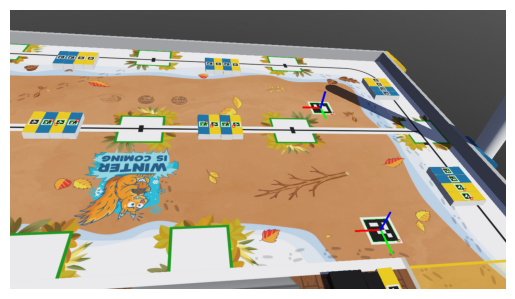

In [5]:
cv2.aruco.drawDetectedMarkers(image, markerCorners)
cv2.drawFrameAxes(image, cameraMatrix, distCoeffs, rvec[0], tvec[0], 0.1) # tag en bas
cv2.drawFrameAxes(image, cameraMatrix, distCoeffs, rvec[1], tvec[1], 0.1) # tag en haut

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Hide the axis

In [10]:
# Detect green squares
squares, squares_cnts = detect_green_squares(image)
print(f"✓ {len(squares)} square(s) detected")

# Estimate pose for each detected square
squares_poses = estimate_square_poses(
    squares=squares,
    square_size=square_size,
    camera_matrix=cameraMatrix,
    dist_coeffs=distCoeffs,
)

✓ 4 square(s) detected



=== Square 0 ===
Position (tvec): [ 0.0845435  -0.04819328  0.87013471]
Rotation (rvec): [ 2.27594903 -0.1021277   0.20866176]
Distance: 0.876 m

=== Square 1 ===
Position (tvec): [-0.26368421 -0.04738802  0.79671719]
Rotation (rvec): [ 2.25807645 -0.0937708   0.20883292]
Distance: 0.841 m

=== Square 2 ===
Position (tvec): [ 0.0843215  -0.27631746  1.14102468]
Rotation (rvec): [ 2.25684696 -0.09000211  0.19743692]
Distance: 1.177 m

=== Square 3 ===
Position (tvec): [-0.31217757 -0.27440677  1.05978412]
Rotation (rvec): [ 2.25333805 -0.09496114  0.20278644]
Distance: 1.138 m

✓ 4 pose(s) estimated


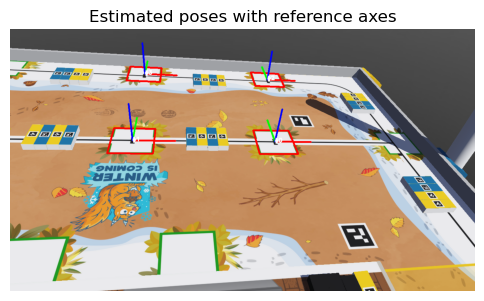

In [11]:
# Draw squares with centers and orientations
squares_result_img = image.copy()
for sq_cnt in squares_cnts:
    cv2.drawContours(squares_result_img, [sq_cnt], -1, (0, 0, 255), 3)

for pose in squares_poses:
    print(f"\n=== Square {pose['id']} ===")
    print(f"Position (tvec): {pose['tvec'].flatten()}")
    print(f"Rotation (rvec): {pose['rvec'].flatten()}")
    print(f"Distance: {np.linalg.norm(pose['tvec']):.3f} m")

print(f"\n✓ {len(squares_poses)} pose(s) estimated")

# Display reference axes for each detected square
squares_result_img = draw_poses(squares_result_img, squares_poses, cameraMatrix, distCoeffs)
show("Estimated poses with reference axes", squares_result_img)

In [12]:
import tf_transformations as tf_trans
from scipy.spatial.transform import Rotation as R

# Vraies positions des ArUco sur la table (world frame)
aruco_0_true_pos = np.array([-0.9, 0.4, 0])  # x,y,z in meters from table center
aruco_1_true_pos = np.array([-0.9, -0.4, 0])  # x,y,z in meters from table center

square_0_true_pose = [0, -0.2, 0]  # x, y, z in meters # middle
square_1_true_pose = [0, -0.7, 0]   # x, y, z in meters # middle bottom
square_2_true_pose = [0.8, -0.2, 0]    # x, y, z in meters # right middle
square_3_true_pose = [0.9, -0.7, 0]    # x, y, z in meters # right bottom

# on considère les squares comme des arucos
aruco_true_positions = [aruco_0_true_pos, aruco_1_true_pos,
                        square_0_true_pose, square_1_true_pose,
                        square_2_true_pose, square_3_true_pose]

# Les ArUco sont posés à plat sur la table, donc rotation de 0 autour de Z
# En ROS: X forward, Y left, Z up - les tags sont orientés vers le haut
aruco_orientation_quat = tf_trans.quaternion_from_euler(0, 0, 0)  # xyzw

# Vraie position et orientation de la caméra (simu)
camera_support_in_world_pos = np.array([-0.225, 1.12, 0.08])  # x,y,z in meters from table center
camera_support_in_world_quat = np.array([0, 0, -0.707105, 0.707105])  # xyzw
camera_in_support_pos = np.array([0, 0, 0.91])  # x,y,z in meters from support frame
camera_in_support_quat = np.array([-0.031363, 0.34146, -0.0859194, 0.935435])  # xyzw

# Appliquer les transformations: T_world_camera = T_world_support @ T_support_camera
# Créer les matrices de transformation
T_world_support = tf_trans.concatenate_matrices(
    tf_trans.translation_matrix(camera_support_in_world_pos),
    tf_trans.quaternion_matrix(camera_support_in_world_quat)
)

T_support_camera = tf_trans.concatenate_matrices(
    tf_trans.translation_matrix(camera_in_support_pos),
    tf_trans.quaternion_matrix(camera_in_support_quat)
)

# Composer les transformations
T_world_camera_true = T_world_support @ T_support_camera

# Extraire position et orientation
camera_pos_in_world = tf_trans.translation_from_matrix(T_world_camera_true)
camera_quat_in_world = tf_trans.quaternion_from_matrix(T_world_camera_true)
camera_euler_in_world = tf_trans.euler_from_quaternion(camera_quat_in_world)

print("=== VRAIE POSITION CAMÉRA (simulation) ===")
print(f"Position: {camera_pos_in_world}")
print(f"Quaternion (xyzw): {camera_quat_in_world}")
print(f"Euler (RPY rad): {camera_euler_in_world}")
print(f"Euler (RPY deg): {np.rad2deg(camera_euler_in_world)}")

=== VRAIE POSITION CAMÉRA (simulation) ===
Position: [-0.225  1.12   0.99 ]
Quaternion (xyzw): (0.21927176258168785, 0.26362575691152335, -0.7222068562693683, 0.6006984361430138)
Euler (RPY rad): (-0.15224587741485085, 0.685988609765597, -1.8084419258870796)
Euler (RPY deg): [  -8.72304622   39.30425213 -103.61608985]


In [13]:

camera_estimates = []

# Pour chaque ArUco détecté (on prend seulement les 2 premiers)
for i in range(2):
    print(f"\n=== Marker {i} ===")
    
    # 1. Transformation camera -> aruco (mesurée par OpenCV)
    rot_mat_cv, _ = cv2.Rodrigues(rvec[i])
    
    # Position de l'ArUco dans le référentiel caméra OpenCV
    tvec_cv = tvec[i][0]
    
    # 2. Créer la matrice de transformation complète camera -> aruco (OpenCV frame)
    T_cam_aruco_cv = np.eye(4)
    T_cam_aruco_cv[:3, :3] = rot_mat_cv
    T_cam_aruco_cv[:3, 3] = tvec_cv
    
    print(f"T_camera_aruco (OpenCV):\n{T_cam_aruco_cv}")
    
    # 3. Transformation OpenCV camera frame -> ROS optical frame
    # OpenCV: X=right, Y=down, Z=forward
    # ROS optical: X=right, Y=down, Z=forward (identique!)
    # Donc pas de transformation nécessaire pour rester en optical frame
    T_cam_aruco_ros = T_cam_aruco_cv.copy()
    
    # 4. Inverser pour obtenir aruco -> camera
    T_aruco_cam = np.linalg.inv(T_cam_aruco_ros)
    
    # 5. Transformation world -> aruco (position vraie)
    T_world_aruco = np.eye(4)
    T_world_aruco[:3, 3] = aruco_true_positions[i]
    # Rotation: ArUco orienté vers le haut (Z up) en ROS frame
    T_world_aruco[:3, :3] = tf_trans.quaternion_matrix(aruco_orientation_quat)[:3, :3]
    
    print(f"T_world_aruco:\n{T_world_aruco}")
    
    # 6. Calculer world -> camera
    T_world_cam = T_world_aruco @ T_aruco_cam
    
    # Extraire position et orientation
    cam_pos = T_world_cam[:3, 3]
    cam_rot_mat = T_world_cam[:3, :3]
    cam_quat = tf_trans.quaternion_from_matrix(T_world_cam)
    cam_euler = tf_trans.euler_from_quaternion(cam_quat)
    
    camera_estimates.append({
        'position': cam_pos,
        'quaternion': cam_quat,
        'euler': cam_euler,
        'transform_matrix': T_world_cam
    })
    
    print(f"\nCamera position (world frame): {cam_pos}")
    print(f"Camera quaternion (xyzw): {cam_quat}")
    print(f"Camera orientation (RPY rad): {cam_euler}")
    print(f"Camera orientation (RPY deg): {np.rad2deg(cam_euler)}")

# Moyenne des estimations
print("\n=== CALIBRATION EXTRINSÈQUE (moyenne des 2 markers) ===")
avg_pos = np.mean([est['position'] for est in camera_estimates], axis=0)
# Pour les quaternions, on fait une moyenne simple (approximation)
avg_quat = np.mean([est['quaternion'] for est in camera_estimates], axis=0)
avg_quat = avg_quat / np.linalg.norm(avg_quat)  # Normaliser
avg_euler = tf_trans.euler_from_quaternion(avg_quat)

print(f"\nCamera position moyenne: {avg_pos}")
print(f"Camera quaternion moyen (xyzw): {avg_quat}")
print(f"Camera orientation moyenne (RPY rad): {avg_euler}")
print(f"Camera orientation moyenne (RPY deg): {np.rad2deg(avg_euler)}")

print("=== VRAIE POSITION CAMÉRA (simulation) ===")
print(f"Position: {camera_pos_in_world}")
print(f"Quaternion (xyzw): {camera_quat_in_world}")
print(f"Euler (RPY rad): {camera_euler_in_world}")
print(f"Euler (RPY deg): {np.rad2deg(camera_euler_in_world)}")

# distance
distance_error = np.linalg.norm(avg_pos - camera_pos_in_world)
print(f"\nErreur de position (distance): {distance_error} m")
# orientation error (angle between quaternions)
dot_product = np.clip(np.dot(avg_quat, camera_quat_in_world), -1.0, 1.0)
angle_error_rad = 2 * np.arccos(dot_product)
angle_error_deg = np.degrees(angle_error_rad)
print(f"Erreur d'orientation: {angle_error_rad} rad ({angle_error_deg} deg)")

# # Commande ROS2 pour static_transform_publisher
# print(f"\n# Commande ROS2:")
# print(f"ros2 run tf2_ros static_transform_publisher {avg_pos[0]:.6f} {avg_pos[1]:.6f} {avg_pos[2]:.6f} " +
#       f"{avg_quat[0]:.6f} {avg_quat[1]:.6f} {avg_quat[2]:.6f} {avg_quat[3]:.6f} world camera_optical_frame")


=== Marker 0 ===
T_camera_aruco (OpenCV):
[[-9.82428140e-01  1.42511232e-01  1.20521774e-01  4.53020735e-01]
 [ 2.39021012e-04  6.46700483e-01 -7.62744012e-01  2.97170278e-01]
 [-1.86641078e-01 -7.49312374e-01 -6.35370816e-01  1.31105338e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
T_world_aruco:
[[ 1.   0.   0.  -0.9]
 [ 0.   1.   0.   0.4]
 [ 0.   0.   1.   0. ]
 [ 0.   0.   0.   1. ]]

Camera position (world frame): [-0.2103143   1.12564782  1.00507104]
Camera quaternion (xyzw): (-0.039503774245513046, -0.9033962916436941, 0.4184366265108024, 0.08500224502353042)
Camera orientation (RPY rad): (-2.2653417608452413, -0.12081547076370355, 2.9975372629499106)
Camera orientation (RPY deg): [-129.79452205   -6.92221657  171.7462341 ]

=== Marker 1 ===
T_camera_aruco (OpenCV):
[[-9.83119394e-01  1.41035462e-01  1.16555802e-01  3.41236509e-01]
 [ 3.12243450e-04  6.38330515e-01 -7.69762338e-01 -2.27700924e-01]
 [-1.82964913e-01 -7.56731889e-01 -6.27599146e-01  1.